# UTS - Kasus 1: Titanic (Tabular)

## 0. Setup & Reproducibility
Pada tahap ini kita menyiapkan library, seed, konfigurasi umum, dan utilitas agar eksperimen dapat direproduksi.

In [67]:
# Tahap setup: validasi environment venv dan import library yang dibutuhkan.
# Jalankan `pip install -r requirements.txt` terlebih dahulu sebelum membuka notebook ini.
required_modules = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'torch']
missing_modules = []
for module_name in required_modules:
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        missing_modules.append(module_name)

if missing_modules:
    raise ModuleNotFoundError(
        'Ada package yang belum terpasang: ' + ', '.join(missing_modules) +
        '. Jalankan `pip install -r requirements.txt` pada environment aktif.'
    )

# Tahap setup: import library yang dibutuhkan untuk EDA, ML, dan DL.
import os
import time
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')


In [68]:
# Tahap reproducibility: set random seed agar hasil eksperimen konsisten.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CONFIG = {
    'seed': SEED,
    'target_col': 'Survived',
    'test_size': 0.2,
    'val_size': 0.2
}
print('Konfigurasi aktif:', CONFIG)


Konfigurasi aktif: {'seed': 42, 'target_col': 'Survived', 'test_size': 0.2, 'val_size': 0.2}


## 1. EDA
Pada tahap ini kita memahami struktur data, distribusi target, missing values, dan pola awal yang relevan.

In [69]:
# Tahap EDA: membuat cache lokal lalu mengunduh dataset jika file belum tersedia.
import urllib.request

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / '.cache' / 'datasets' / 'titanic'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def download_if_missing(urls, out_path):
    if out_path.exists():
        return out_path
    for url in urls:
        try:
            print(f'Download: {url}')
            urllib.request.urlretrieve(url, out_path)
            return out_path
        except Exception as e:
            print(f'Gagal dari {url}: {e}')
    return None

train_urls = [
    'https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/train.csv'
]
test_urls = [
    'https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/test.csv'
]

cached_train = download_if_missing(train_urls, CACHE_DIR / 'train.csv')
cached_test = download_if_missing(test_urls, CACHE_DIR / 'test.csv')

TRAIN_CANDIDATES = [
    cached_train,
    BASE_DIR / 'data' / 'titanic' / 'train.csv',
    BASE_DIR / 'datasets' / 'titanic' / 'train.csv',
    BASE_DIR / 'train.csv',
]
TEST_CANDIDATES = [
    cached_test,
    BASE_DIR / 'data' / 'titanic' / 'test.csv',
    BASE_DIR / 'datasets' / 'titanic' / 'test.csv',
    BASE_DIR / 'test.csv',
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if (p is not None and p.exists())), None)
TEST_PATH = next((p for p in TEST_CANDIDATES if (p is not None and p.exists())), None)
if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(
        'File Titanic tidak ditemukan. Pastikan internet aktif atau simpan train.csv dan test.csv di data/titanic/.'
    )

df = pd.read_csv(TRAIN_PATH)
df_test_kaggle = pd.read_csv(TEST_PATH)
print('Path train:', TRAIN_PATH)
print('Path test:', TEST_PATH)
print('Ukuran train:', df.shape)
print('Ukuran test kaggle:', df_test_kaggle.shape)
df.head()


Path train: c:\Users\muham\Kuliah\Ekstensi\Semester Genap 25-26\Pengantar Deep Learning\UTS\notebooks\.cache\datasets\titanic\train.csv
Path test: c:\Users\muham\Kuliah\Ekstensi\Semester Genap 25-26\Pengantar Deep Learning\UTS\notebooks\.cache\datasets\titanic\test.csv
Ukuran train: (891, 12)
Ukuran test kaggle: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
# Tahap EDA: cek info data, missing values, dan distribusi kelas target.
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(10))
display(df[CONFIG['target_col']].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
dtype: int64

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

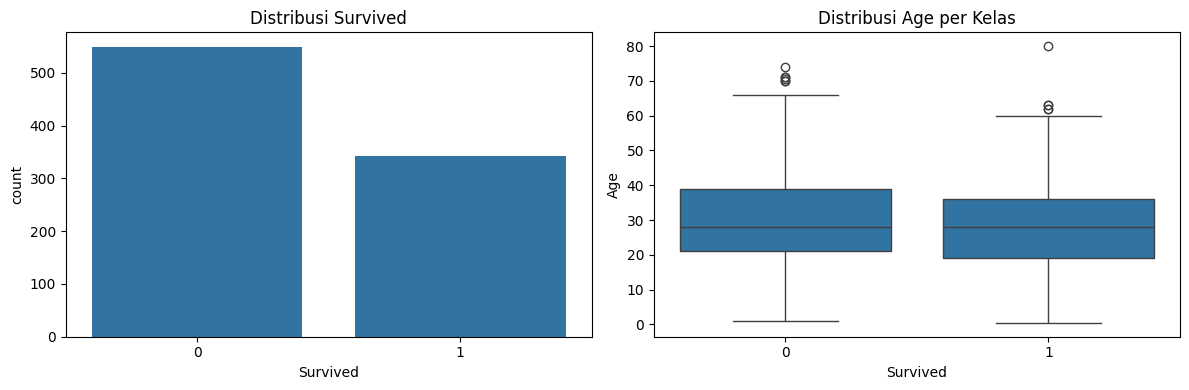

In [71]:
# Tahap EDA: visualisasi dasar untuk memahami distribusi target dan relasi fitur penting.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Survived', ax=axes[0])
axes[0].set_title('Distribusi Survived')
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[1])
axes[1].set_title('Distribusi Age per Kelas')
plt.tight_layout()
plt.show()


## 2. Preprocessing
Tahap ini menyiapkan feature engineering, split data yang fair, dan pipeline transformasi untuk model klasik dan deep learning.

In [72]:
# Tahap preprocessing: feature engineering sederhana (title dan family_size).
def add_titanic_features(dataframe):
    data = dataframe.copy()
    data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    return data

df_feat = add_titanic_features(df)
target = CONFIG['target_col']
X = df_feat.drop(columns=[target])
y = df_feat[target]
print('Jumlah fitur awal:', X.shape[1])


Jumlah fitur awal: 14


In [73]:
# Tahap preprocessing: split train/valid/test agar perbandingan antar model adil.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=CONFIG['val_size'], random_state=SEED, stratify=y_train_full
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (569, 14) Val: (143, 14) Test: (179, 14)


In [74]:
# Tahap preprocessing: menyiapkan pipeline numerik dan kategorikal untuk baseline ML.
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)
print('Fitur numerik:', len(numeric_features), '| Fitur kategorikal:', len(categorical_features))


Fitur numerik: 8 | Fitur kategorikal: 6


## 3. Baseline ML
Tahap ini melatih minimal 2 model machine learning konvensional sebagai pembanding yang fair.

In [75]:
# Tahap baseline ML: melatih Logistic Regression dengan pipeline preprocessing.
baseline_results = []

logreg = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=200, random_state=SEED))
])

start = time.perf_counter()
logreg.fit(X_train, y_train)
train_time = time.perf_counter() - start

val_pred = logreg.predict(X_val)
acc = accuracy_score(y_val, val_pred)
baseline_results.append({'model': 'LogReg', 'val_accuracy': acc, 'train_time_sec': train_time})
print('LogReg val accuracy:', round(acc, 4))


LogReg val accuracy: 0.8182


In [76]:
# Tahap baseline ML: melatih Random Forest sebagai baseline kedua.
rf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=SEED))
])

start = time.perf_counter()
rf.fit(X_train, y_train)
train_time = time.perf_counter() - start

val_pred = rf.predict(X_val)
acc = accuracy_score(y_val, val_pred)
baseline_results.append({'model': 'RandomForest', 'val_accuracy': acc, 'train_time_sec': train_time})
print('RandomForest val accuracy:', round(acc, 4))
pd.DataFrame(baseline_results)


RandomForest val accuracy: 0.8392


,model,val_accuracy,train_time_sec
0,LogReg,0.818182,0.033995
1,RandomForest,0.839161,0.619200


## 4. Deep Learning
Tahap ini melatih model deep learning tabular (MLP) dengan regularisasi dan early stopping.

In [77]:
# Tahap deep learning: transform data tabular ke array numerik untuk MLP PyTorch.
X_train_dl = preprocessor.fit_transform(X_train, y_train)
X_val_dl = preprocessor.transform(X_val)
X_test_dl = preprocessor.transform(X_test)

if hasattr(X_train_dl, 'toarray'):
    X_train_dl = X_train_dl.toarray()
    X_val_dl = X_val_dl.toarray()
    X_test_dl = X_test_dl.toarray()

X_train_dl = np.asarray(X_train_dl, dtype=np.float32)
X_val_dl = np.asarray(X_val_dl, dtype=np.float32)
X_test_dl = np.asarray(X_test_dl, dtype=np.float32)

y_train_dl = y_train.to_numpy(dtype=np.float32)
y_val_dl = y_val.to_numpy(dtype=np.float32)
y_test_dl = y_test.to_numpy(dtype=np.float32)

print('Shape input MLP:', X_train_dl.shape)


Shape input MLP: (569, 1176)


In [78]:
# Tahap deep learning: mendefinisikan arsitektur MLP PyTorch dan melatih model.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(torch.from_numpy(X_train_dl), torch.from_numpy(y_train_dl.reshape(-1, 1)))
val_ds = TensorDataset(torch.from_numpy(X_val_dl), torch.from_numpy(y_val_dl.reshape(-1, 1)))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

class TitanicMLP(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

mlp = TitanicMLP(X_train_dl.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

best_val_loss = float('inf')
best_state = None
patience = 10
wait = 0
max_epochs = 100

start = time.perf_counter()
for epoch in range(max_epochs):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    mlp.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = mlp(xb)
            vloss = criterion(logits, yb)
            val_losses.append(vloss.item())

    avg_val_loss = float(np.mean(val_losses))
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

if best_state is not None:
    mlp.load_state_dict(best_state)

dl_train_time = time.perf_counter() - start
print('Training MLP PyTorch selesai, durasi (detik):', round(dl_train_time, 2))


Training MLP PyTorch selesai, durasi (detik): 0.85


## 5. Evaluasi
Tahap ini membandingkan performa baseline ML dan deep learning menggunakan metrik yang sama.

In [79]:
# Tahap evaluasi: menghitung metrik untuk semua model pada test set.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlp.eval()
with torch.no_grad():
    test_logits = mlp(torch.from_numpy(X_test_dl).to(device)).cpu().numpy().ravel()
mlp_test_proba = 1 / (1 + np.exp(-test_logits))
mlp_test_pred = (mlp_test_proba >= 0.5).astype(int)

models = {'LogReg': logreg, 'RandomForest': rf}
test_preds = {}
for name, model in models.items():
    test_preds[name] = model.predict(X_test)
test_preds['MLP'] = mlp_test_pred

eval_results = []
for name, pred in test_preds.items():
    eval_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1_score': f1_score(y_test, pred)
    })
comparison_df = pd.DataFrame(eval_results)
display(comparison_df.sort_values('accuracy', ascending=False))


,model,accuracy,precision,recall,f1_score
0,LogReg,0.826816,0.771429,0.782609,0.776978
1,RandomForest,0.815642,0.781250,0.724638,0.751880
2,MLP,0.810056,0.746479,0.768116,0.757143


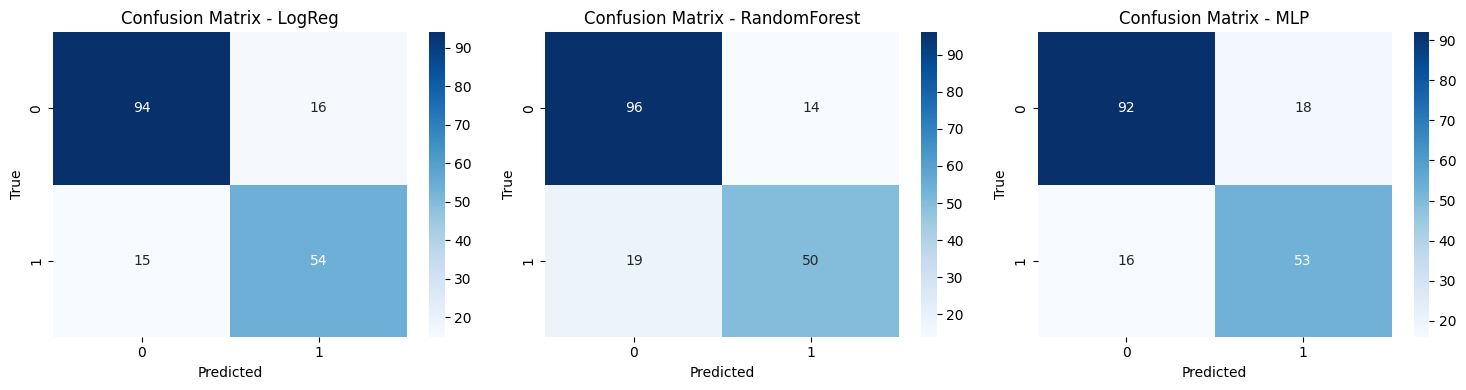

In [80]:
# Tahap evaluasi: menampilkan confusion matrix untuk semua model (side-by-side).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


## 6. Error Analysis
Tahap ini mengidentifikasi contoh prediksi yang salah, menganalisis penyebabnya, lalu membandingkan pola error antar pendekatan.

In [81]:
# Gabungkan hasil prediksi ketiga model ke dalam satu DataFrame untuk mempermudah perbandingan
error_df = X_test.copy()
error_df['Actual_Survived'] = y_test.values if hasattr(y_test, 'values') else y_test
error_df['Pred_LogReg'] = test_preds['LogReg']
error_df['Pred_RandomForest'] = test_preds['RandomForest']
error_df['Pred_MLP'] = test_preds['MLP']

# Cari penumpang yang salah ditebak oleh MLP PyTorch (DL) tapi mungkin benar di model klasik
dl_errors = error_df[error_df['Actual_Survived'] != error_df['Pred_MLP']]

print(f"Total kesalahan prediksi MLP: {len(dl_errors)} dari {len(y_test)} data")
print("\n--- 5 Contoh Data yang Salah Ditebak oleh MLP PyTorch ---")
display(dl_errors.head())

# Cari penumpang yang salah ditebak oleh SEMUA model (hard examples / noise)
all_errors = error_df[
    (error_df['Actual_Survived'] != error_df['Pred_LogReg']) &
    (error_df['Actual_Survived'] != error_df['Pred_RandomForest']) &
    (error_df['Actual_Survived'] != error_df['Pred_MLP'])
]
print(f"\nTotal penumpang yang salah ditebak oleh KETIGA model: {len(all_errors)}")
print("--- 5 Contoh Penumpang yang Sangat Sulit Ditebak (Hard Examples) ---")
display(all_errors.head())


Total kesalahan prediksi MLP: 34 dari 179 data

--- 5 Contoh Data yang Salah Ditebak oleh MLP PyTorch ---


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Actual_Survived,Pred_LogReg,Pred_RandomForest,Pred_MLP
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C,Mr,1,1,1,0,0,0
536,537,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S,Major,1,1,0,1,1,1
698,699,1,"Thayer, Mr. John Borland",male,49.0,1,1,17421,110.8833,C68,C,Mr,3,0,0,0,1,1
712,713,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S,Mr,2,0,1,0,0,0
455,456,3,"Jalsevac, Mr. Ivan",male,29.0,0,0,349240,7.8958,NaN,C,Mr,1,1,1,0,0,0



Total penumpang yang salah ditebak oleh KETIGA model: 22
--- 5 Contoh Penumpang yang Sangat Sulit Ditebak (Hard Examples) ---


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Actual_Survived,Pred_LogReg,Pred_RandomForest,Pred_MLP
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C,Mr,1,1,1,0,0,0
536,537,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S,Major,1,1,0,1,1,1
712,713,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S,Mr,2,0,1,0,0,0
455,456,3,"Jalsevac, Mr. Ivan",male,29.0,0,0,349240,7.8958,NaN,C,Mr,1,1,1,0,0,0
297,298,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,Miss,4,0,0,1,1,1


## 7. Kesimpulan
1. **Model Terbaik:** Logistic Regression menjadi model dengan performa terbaik pada *test set* dengan **Akurasi ~82.68%** dan **F1-Score ~77.69%**, sedikit mengungguli Random Forest (Akurasi 81.56%) dan MLP PyTorch (Akurasi 81.00%).
2. **Deep Learning vs ML Konvensional:** Untuk dataset tabular berukuran kecil dan sederhana seperti Titanic, Deep Learning (MLP) tidak selalu lebih unggul dibanding ML Konvensional. Logistic Regression terbukti lebih tangguh, jauh lebih cepat dilatih (komputasi sangat rendah), dan parameternya jauh lebih mudah diinterpretasikan.
3. **Analisis Kesalahan (Error Analysis):** Dari sampel error, model sangat mengandalkan fitur `Sex` (Jenis Kelamin) dan `Pclass` (Kelas Tiket). Model sering kali salah memprediksi ketika terjadi anomali, seperti pria dewasa di kelas 3 yang ternyata selamat (contoh: *Fahim Leeni*), atau perempuan/anak-anak di kelas VIP yang nahasnya meninggal (contoh: *Helen Loraine Allison*).
4. **Rekomendasi Lanjutan:** Untuk meningkatkan akurasi, dapat dilakukan *feature engineering* yang lebih kompleks (seperti menganalisis letak Dek/Cabin atau detail relasi keluarga). Eksperimen dengan model *Gradient Boosting* (seperti XGBoost atau LightGBM) juga sangat direkomendasikan untuk data tabular seperti ini.